In [4]:
import pandas as pd
url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch07/customer.csv'
df = pd.read_csv(url)
print(df.head( ))


         Age         Income  Purchased
0  39.967142   78033.985988          0
1  33.617357  261173.924513          1
2  41.476885   35891.567445          1
3  50.230299   67563.459278          0
4  32.658466  137995.909721          0


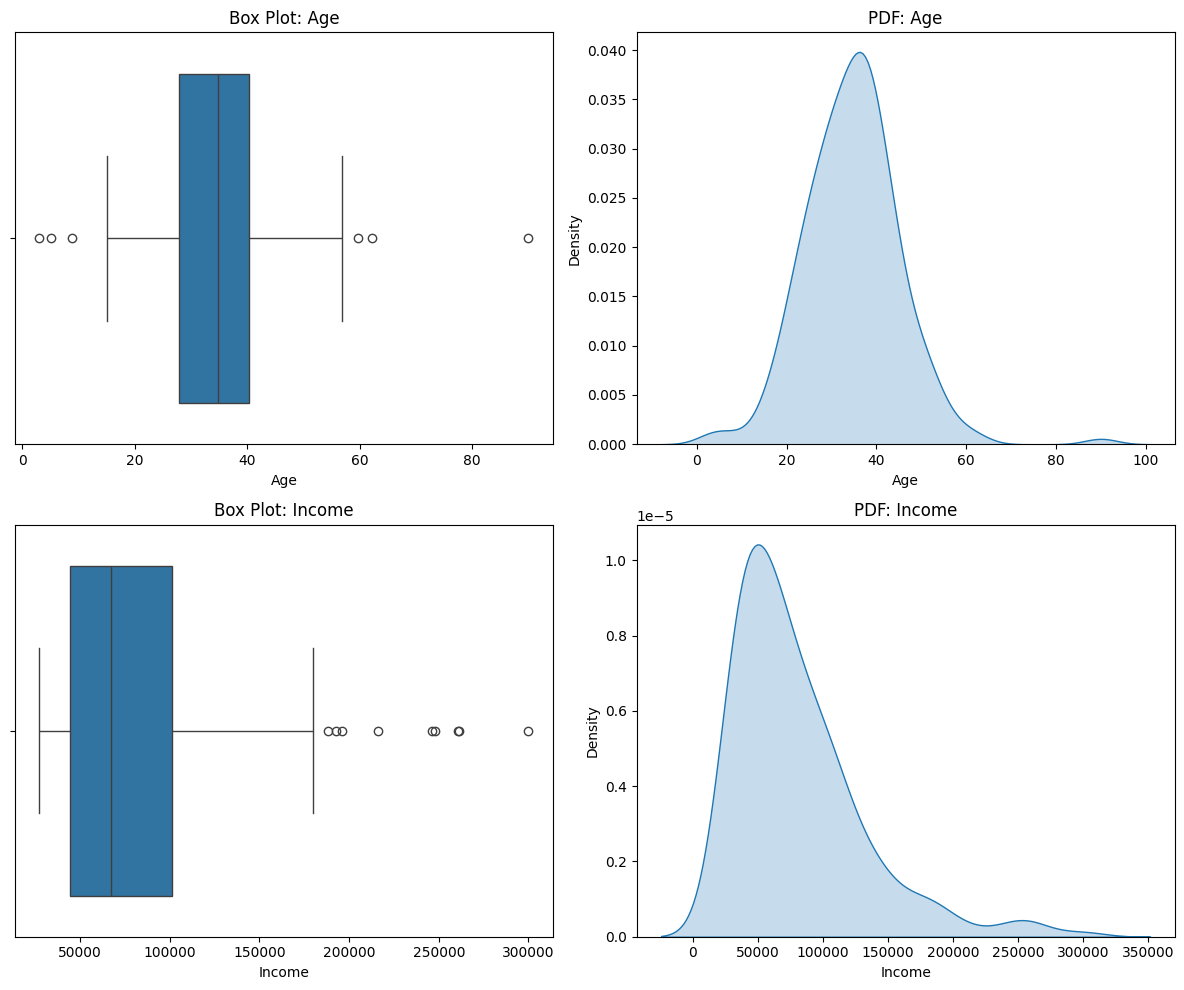

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize = (12, 10))
sns.boxplot(x = df['Age'], ax = axes[0, 0])
axes[0, 0].set_title('Box Plot: Age')
sns.kdeplot(df['Age'], ax = axes[0, 1], fill = True)
axes[0, 1].set_title('PDF: Age')
sns.boxplot(x = df['Income'], ax = axes[1, 0])
axes[1, 0].set_title('Box Plot: Income')
sns.kdeplot(df['Income'], ax = axes[1, 1], fill = True)
axes[1, 1].set_title('PDF: Income')
plt.tight_layout( )
plt.show( )


In [6]:
mean_age = df['Age'].mean( )
std_age = df['Age'].std( )
df['Age_Z_Score'] = (df['Age'] - mean_age) / std_age
age_outliers = df[(df['Age_Z_Score'] > 3) | (df['Age_Z_Score'] < -3)]
print(age_outliers)

q1_income = df['Income'].quantile(0.25)
q3_income = df['Income'].quantile(0.75)
iqr_income = q3_income - q1_income
lower_bound_income = q1_income - 1.5 * iqr_income
upper_bound_income = q3_income + 1.5 * iqr_income
income_outliers = df[(df['Income'] < lower_bound_income) |
                                (df['Income'] > upper_bound_income)]
print(income_outliers)


      Age        Income  Purchased  Age_Z_Score
197  90.0  62292.923803          0      5.24624
           Age         Income  Purchased  Age_Z_Score
1    33.617357  261173.924513          1    -0.096684
45   27.801558  216188.337834          0    -0.647800
50   45.000000  300000.000000          0     0.981957
53   41.116763  195792.225920          0     0.613974
64   43.125258  188415.856613          0     0.804303
106  53.861859  192882.552897          1     1.821723
130  19.493366  260687.148500          1    -1.435099
181  26.428424  247785.513721          0    -0.777920
186  39.732376  246321.834221          0     0.482787


In [7]:
mean_age = df['Age'].mean( )
std_age = df['Age'].std( )
df['Age_Z_Score'] = (df['Age'] - mean_age) / std_age
age_outliers = df[(df['Age_Z_Score'] > 3) | (df['Age_Z_Score'] < -3)]
print(age_outliers)

q1_income = df['Income'].quantile(0.25)
q3_income = df['Income'].quantile(0.75)
iqr_income = q3_income - q1_income
lower_bound_income = q1_income - 1.5 * iqr_income
upper_bound_income = q3_income + 1.5 * iqr_income
income_outliers = df[(df['Income'] < lower_bound_income) | (df['Income'] > upper_bound_income)]
print(income_outliers)

# removal
data_no_outliers = df[~((df['Age_Z_Score'] > 3) |
                                  (df['Age_Z_Score'] < -3))]
data_no_outliers = data_no_outliers[~((data_no_outliers['Income'] < lower_bound_income) | (data_no_outliers['Income']> upper_bound_income))]
print(data_no_outliers)

# capping
data_capped = df.copy( )
data_capped ['Age'] = data_capped ['Age'].clip(lower = mean_age - 3 * std_age, upper = mean_age + 3 * std_age)
data_capped['Income'] = data_capped['Income'].clip(lower = lower_bound_income, upper = upper_bound_income)
print(data_capped)


      Age        Income  Purchased  Age_Z_Score
197  90.0  62292.923803          0      5.24624
           Age         Income  Purchased  Age_Z_Score
1    33.617357  261173.924513          1    -0.096684
45   27.801558  216188.337834          0    -0.647800
50   45.000000  300000.000000          0     0.981957
53   41.116763  195792.225920          0     0.613974
64   43.125258  188415.856613          0     0.804303
106  53.861859  192882.552897          1     1.821723
130  19.493366  260687.148500          1    -1.435099
181  26.428424  247785.513721          0    -0.777920
186  39.732376  246321.834221          0     0.482787
           Age         Income  Purchased  Age_Z_Score
0    39.967142   78033.985988          0     0.505034
2    41.476885   35891.567445          1     0.648100
3    50.230299   67563.459278          0     1.477589
4    32.658466  137995.909721          0    -0.187550
5    32.658630   97284.192121          1    -0.187534
..         ...            ...        ...